# Introduction and Assignment Objective

This notebook builds a **Decision Tree classification model** for FitLife Studio Analytics. The purpose of the model is to predict whether a member is **at risk of not renewing** their fitness membership.

The assignment focuses on both the technical model results and the business interpretation of those results. Therefore, the notebook follows a clear machine learning workflow: understanding the business problem, preparing the data, training a Decision Tree model, evaluating the model, checking for overfitting, identifying important features, and explaining how the results can support FitLife's retention decisions.

# Step 1: Business Problem and Dataset Overview

FitLife Studio is a fitness subscription business that sells monthly, six-month, and annual memberships. Since a large part of its revenue depends on recurring membership renewals, customer retention is an important business priority.

The main business problem is **membership churn**. Some members may become less engaged before they decide not to renew. For example, they may attend fewer classes, use the app less often, report lower satisfaction, experience payment issues, or show weaker interaction with the studio.

The business question is:

**Can FitLife predict whether a member is at risk of not renewing their membership using member information, engagement data, satisfaction indicators, payment information, membership details, and contextual features?**

The Decision Tree model can help FitLife identify members who may need proactive retention support, such as personalized class recommendations, check-in messages, service recovery follow-up, billing support, renewal reminders, or targeted retention offers.

# Step 2: Loading the Dataset

In this step, the FitLife membership renewal risk dataset is loaded into Python.

The dataset file should be stored in the same folder as this notebook. The data is loaded into a pandas DataFrame named `df`.

In [1]:
# Import pandas library to work with datasets
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for charts and visualizations
import matplotlib.pyplot as plt

# Import display function to show tables clearly in Jupyter Notebook
from IPython.display import display

# Import train_test_split to split the dataset into training and testing data
from sklearn.model_selection import train_test_split

# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Import Decision Tree classifier and visualization tools
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Import warnings to hide unnecessary Excel formatting warnings
import warnings

# Import os to create output folders
import os

# Hide openpyxl warnings about Excel formatting
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Create an outputs folder to save charts and result files
os.makedirs("outputs", exist_ok=True)

# Print a confirmation message
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Store the Excel file name in a variable
# Important: Keep the dataset file in the same folder as this notebook
file_path = "fitlife_membership_renewal_risk_dataset.xlsx"

# Read the Dataset sheet from the Excel file and load it into a pandas DataFrame
df = pd.read_excel(file_path, sheet_name="Dataset")

# Print a message to confirm that the dataset has been loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (416, 21)


,Member_ID,Age,Gender,Membership_Type,Monthly_Fee,Months_As_Member,Contract_Type,Avg_Weekly_Visits,Classes_Per_Month,Personal_Training,...,Payment_Issues_Last_6_Months,Satisfaction_Score,Complaint_Count_Last_3_Months,Distance_From_Studio_km,Last_Renewal_Discount_Used,Renewal_Reminder_Sent,Corporate_Plan,Season,Referral_Source,At_Risk_Not_Renewing
0,FS-0001,33,Male,Standard,69,4,Monthly,2.5,2.0,No,...,0,6.4,0,13.7,No,No,No,Spring,Instagram Ad,No
1,FS-0002,24,Female,Standard,69,8,Monthly,4.3,4.0,Yes,...,1,6.5,0,2.7,No,Yes,No,Spring,Community Event,No
2,FS-0003,43,Female,Basic,49,25,6-Month,1.9,1.0,No,...,2,9.7,0,11.4,No,Yes,Yes,Winter,Corporate Partner,Yes
3,FS-0004,57,Prefer not to say,Student,35,27,Annual,2.7,6.0,Yes,...,0,NaN,1,5.9,No,Yes,Yes,Fall,Instagram Ad,No
4,FS-0005,35,Female,Standard,54,1,6-Month,3.1,1.0,No,...,2,7.6,1,5.2,No,Yes,No,Spring,Friend Referral,Yes


# Step 3: Initial Data Inspection

Before building the model, the dataset must be inspected carefully. This step helps us understand the structure of the data, the number of rows and columns, the column names, data types, missing values, duplicate rows, and basic summary statistics.

In [3]:
# Print a title for this output
print("Dataset Shape")

# Print a separator line
print("-" * 50)

# Display the number of rows and columns
print(df.shape)

Dataset Shape
--------------------------------------------------
(416, 21)


In [4]:
# Print a title for this output
print("First Five Rows of the Dataset")

# Print a separator line
print("-" * 50)

# Display the first five rows
display(df.head())

First Five Rows of the Dataset
--------------------------------------------------


,Member_ID,Age,Gender,Membership_Type,Monthly_Fee,Months_As_Member,Contract_Type,Avg_Weekly_Visits,Classes_Per_Month,Personal_Training,...,Payment_Issues_Last_6_Months,Satisfaction_Score,Complaint_Count_Last_3_Months,Distance_From_Studio_km,Last_Renewal_Discount_Used,Renewal_Reminder_Sent,Corporate_Plan,Season,Referral_Source,At_Risk_Not_Renewing
0,FS-0001,33,Male,Standard,69,4,Monthly,2.5,2.0,No,...,0,6.4,0,13.7,No,No,No,Spring,Instagram Ad,No
1,FS-0002,24,Female,Standard,69,8,Monthly,4.3,4.0,Yes,...,1,6.5,0,2.7,No,Yes,No,Spring,Community Event,No
2,FS-0003,43,Female,Basic,49,25,6-Month,1.9,1.0,No,...,2,9.7,0,11.4,No,Yes,Yes,Winter,Corporate Partner,Yes
3,FS-0004,57,Prefer not to say,Student,35,27,Annual,2.7,6.0,Yes,...,0,NaN,1,5.9,No,Yes,Yes,Fall,Instagram Ad,No
4,FS-0005,35,Female,Standard,54,1,6-Month,3.1,1.0,No,...,2,7.6,1,5.2,No,Yes,No,Spring,Friend Referral,Yes


In [5]:
# Print a title for this output
print("Last Five Rows of the Dataset")

# Print a separator line
print("-" * 50)

# Display the last five rows
display(df.tail())

Last Five Rows of the Dataset
--------------------------------------------------


,Member_ID,Age,Gender,Membership_Type,Monthly_Fee,Months_As_Member,Contract_Type,Avg_Weekly_Visits,Classes_Per_Month,Personal_Training,...,Payment_Issues_Last_6_Months,Satisfaction_Score,Complaint_Count_Last_3_Months,Distance_From_Studio_km,Last_Renewal_Discount_Used,Renewal_Reminder_Sent,Corporate_Plan,Season,Referral_Source,At_Risk_Not_Renewing
411,FS-0165,53,Male,Premium,89,72,Annual,1.9,5.0,No,...,0,7.7,0,5.5,No,Yes,No,Fall,Google Search,No
412,FS-0209,33,Male,Premium,99,70,Annual,2.1,6.0,No,...,0,7.5,0,1.8,Yes,No,No,Summer,Google Search,No
413,FS-0194,57,Female,Standard,59,29,Monthly,4.1,3.0,No,...,1,9.6,0,2.4,No,Yes,No,Fall,Walk-in,No
414,FS-0022,31,Male,Basic,34,16,6-Month,0.0,6.0,No,...,0,7.7,0,6.1,No,No,No,Summer,Friend Referral,Yes
415,FS-0210,52,Male,Standard,64,21,Monthly,4.7,2.0,No,...,1,6.9,1,14.2,Yes,No,No,Winter,Corporate Partner,No


In [6]:
# Print a title for this output
print("Column Names")

# Print a separator line
print("-" * 50)

# Display all column names as a list
print(df.columns.tolist())

Column Names
--------------------------------------------------
['Member_ID', 'Age', 'Gender', 'Membership_Type', 'Monthly_Fee', 'Months_As_Member', 'Contract_Type', 'Avg_Weekly_Visits', 'Classes_Per_Month', 'Personal_Training', 'App_Login_Days_Last_30', 'Payment_Issues_Last_6_Months', 'Satisfaction_Score', 'Complaint_Count_Last_3_Months', 'Distance_From_Studio_km', 'Last_Renewal_Discount_Used', 'Renewal_Reminder_Sent', 'Corporate_Plan', 'Season', 'Referral_Source', 'At_Risk_Not_Renewing']


In [7]:
# Print a title for this output
print("Dataset Information")

# Print a separator line
print("-" * 50)

# Display column names, non-null counts, and data types
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Member_ID                      416 non-null    object 
 1   Age                            416 non-null    int64  
 2   Gender                         416 non-null    object 
 3   Membership_Type                416 non-null    object 
 4   Monthly_Fee                    416 non-null    int64  
 5   Months_As_Member               416 non-null    int64  
 6   Contract_Type                  416 non-null    object 
 7   Avg_Weekly_Visits              411 non-null    float64
 8   Classes_Per_Month              408 non-null    float64
 9   Personal_Training              416 non-null    object 
 10  App_Login_Days_Last_30         416 non-null    int64  
 11  Payment_Issues_Last_6_Months   416 non-

In [8]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


Member_ID                         object
Age                                int64
Gender                            object
Membership_Type                   object
Monthly_Fee                        int64
Months_As_Member                   int64
Contract_Type                     object
Avg_Weekly_Visits                float64
Classes_Per_Month                float64
Personal_Training                 object
App_Login_Days_Last_30             int64
Payment_Issues_Last_6_Months       int64
Satisfaction_Score               float64
Complaint_Count_Last_3_Months      int64
Distance_From_Studio_km          float64
Last_Renewal_Discount_Used        object
Renewal_Reminder_Sent             object
Corporate_Plan                    object
Season                            object
Referral_Source                   object
At_Risk_Not_Renewing              object
dtype: object

In [9]:
# Print a title for this output
print("Missing Values in Each Column")

# Print a separator line
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display missing values
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Member_ID                        0
Age                              0
Gender                           0
Membership_Type                  0
Monthly_Fee                      0
Months_As_Member                 0
Contract_Type                    0
Avg_Weekly_Visits                5
Classes_Per_Month                8
Personal_Training                0
App_Login_Days_Last_30           0
Payment_Issues_Last_6_Months     0
Satisfaction_Score               9
Complaint_Count_Last_3_Months    0
Distance_From_Studio_km          0
Last_Renewal_Discount_Used       0
Renewal_Reminder_Sent            0
Corporate_Plan                   0
Season                           0
Referral_Source                  7
At_Risk_Not_Renewing             0
dtype: int64

In [10]:
# Print a title for this output
print("Number of Duplicate Rows")

# Print a separator line
print("-" * 50)

# Count duplicate rows
duplicate_rows = df.duplicated().sum()

# Display duplicate row count
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
6


In [11]:
# Print a title for this output
print("Summary Statistics for Numerical Columns")

# Print a separator line
print("-" * 50)

# Display summary statistics for numerical columns
display(df.describe())

Summary Statistics for Numerical Columns
--------------------------------------------------


,Age,Monthly_Fee,Months_As_Member,Avg_Weekly_Visits,Classes_Per_Month,App_Login_Days_Last_30,Payment_Issues_Last_6_Months,Satisfaction_Score,Complaint_Count_Last_3_Months,Distance_From_Studio_km
count,416.000000,416.000000,416.000000,411.000000,408.000000,416.000000,416.000000,407.000000,416.000000,416.000000
mean,35.769231,64.723558,17.759615,2.559367,3.568627,16.745192,0.442308,7.625061,0.427885,6.217067
std,10.767851,24.232469,16.402318,1.206963,3.044340,5.829090,0.742213,1.614989,0.847159,4.006708
min,18.000000,30.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2.400000,0.000000,0.600000
25%,27.750000,44.000000,6.000000,1.700000,1.000000,13.000000,0.000000,6.600000,0.000000,3.500000
50%,35.000000,59.000000,12.000000,2.500000,3.000000,16.000000,0.000000,7.600000,0.000000,5.200000
75%,44.000000,84.000000,24.250000,3.300000,6.000000,21.000000,1.000000,8.900000,1.000000,7.600000
max,64.000000,119.000000,72.000000,6.300000,12.000000,30.000000,3.000000,10.000000,4.000000,27.700000


In [12]:
# Print a title for this output
print("Summary Statistics for Categorical Columns")

# Print a separator line
print("-" * 50)

# Display summary statistics for categorical/text columns
display(df.describe(include=["object"]))

Summary Statistics for Categorical Columns
--------------------------------------------------


,Member_ID,Gender,Membership_Type,Contract_Type,Personal_Training,Last_Renewal_Discount_Used,Renewal_Reminder_Sent,Corporate_Plan,Season,Referral_Source,At_Risk_Not_Renewing
count,416,416,416,416,416,416,416,416,416,409,416
unique,410,4,5,3,2,2,2,2,4,6,2
top,FS-0115,Male,Standard,Monthly,No,No,Yes,No,Winter,Friend Referral,No
freq,2,202,167,204,340,322,260,326,112,104,253


## Short Interpretation

The initial inspection shows the size and structure of the FitLife dataset. The dataset contains both numerical and categorical variables, which means categorical variables must be converted into a numerical format before training the Decision Tree model. The inspection also identifies missing values and duplicate rows that need to be handled before modeling.

# Step 4: Understanding Features, Target Variable, and Target Distribution

The **target variable** is the column the model will predict. In this assignment, the target variable is `At_Risk_Not_Renewing`.

- `Yes` means the member is at risk of not renewing.
- `No` means the member is not currently considered high risk.

The **input features** are the remaining useful columns that help the model make the prediction. The `Member_ID` column is an identifier and is not used as a model feature.

The purpose of this step is to clearly identify what the model will predict and which variables may help make that prediction.

In [13]:
# Define the target column
target_column = "At_Risk_Not_Renewing"

# Define the ID column
id_column = "Member_ID"

# Print the target variable
print("Target Variable")

# Print a separator line
print("-" * 50)

# Display the target variable name
print(target_column)

Target Variable
--------------------------------------------------
At_Risk_Not_Renewing


In [14]:
# Print the unique values in the target variable
print("Target Variable Values")

# Print a separator line
print("-" * 50)

# Display unique target values as a clean list
print(df[target_column].unique().tolist())

Target Variable Values
--------------------------------------------------
['No', 'Yes']


In [15]:
# Create a list of input feature columns by removing the target column and ID column
input_features = df.drop(columns=[target_column, id_column]).columns.tolist()

# Print a title
print("Input Feature Columns")

# Print a separator line
print("-" * 50)

# Display input feature columns
print(input_features)

Input Feature Columns
--------------------------------------------------
['Age', 'Gender', 'Membership_Type', 'Monthly_Fee', 'Months_As_Member', 'Contract_Type', 'Avg_Weekly_Visits', 'Classes_Per_Month', 'Personal_Training', 'App_Login_Days_Last_30', 'Payment_Issues_Last_6_Months', 'Satisfaction_Score', 'Complaint_Count_Last_3_Months', 'Distance_From_Studio_km', 'Last_Renewal_Discount_Used', 'Renewal_Reminder_Sent', 'Corporate_Plan', 'Season', 'Referral_Source']


In [16]:
# Count the number of records in each target class
target_distribution = df[target_column].value_counts()

# Print a title
print("Target Class Distribution")

# Print a separator line
print("-" * 50)

# Display the target class distribution
display(target_distribution)

Target Class Distribution
--------------------------------------------------


At_Risk_Not_Renewing
No     253
Yes    163
Name: count, dtype: int64

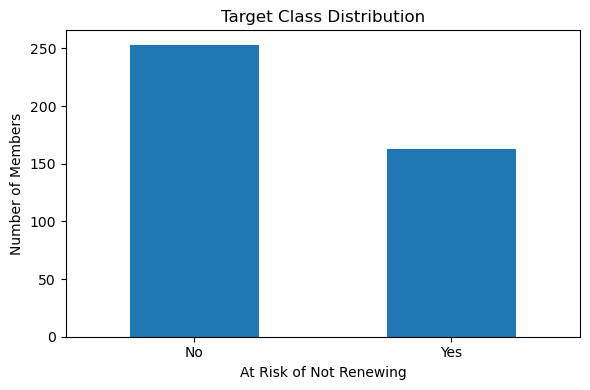

In [17]:
# Create a bar chart for target class distribution
plt.figure(figsize=(6, 4))

# Plot the target class distribution
target_distribution.plot(kind="bar")

# Add chart title and labels
plt.title("Target Class Distribution")
plt.xlabel("At Risk of Not Renewing")
plt.ylabel("Number of Members")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/target_class_distribution.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## Short Interpretation

The target variable has two classes: `Yes` and `No`. This confirms that the task is a binary classification problem. The target distribution also shows how many members are classified as at risk and not at risk in the dataset.

# Step 5: Checking Numerical and Categorical Variables

In this step, the dataset is separated into numerical and categorical feature columns. This is important because numerical and categorical variables are handled differently during preprocessing.

The `Member_ID` column is excluded because it is only an identifier, and the target column is excluded because it is the value the model is trying to predict.

In [18]:
# Create a feature-only dataset by removing the target column and ID column
feature_data = df.drop(columns=[target_column, id_column])

# Select numerical feature columns
numerical_features_initial = feature_data.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns
categorical_features_initial = feature_data.select_dtypes(include=["object"]).columns.tolist()

# Print numerical feature columns
print("Numerical Feature Columns")
print("-" * 50)
print(numerical_features_initial)

# Print categorical feature columns
print("\nCategorical Feature Columns")
print("-" * 50)
print(categorical_features_initial)

Numerical Feature Columns
--------------------------------------------------
['Age', 'Monthly_Fee', 'Months_As_Member', 'Avg_Weekly_Visits', 'Classes_Per_Month', 'App_Login_Days_Last_30', 'Payment_Issues_Last_6_Months', 'Satisfaction_Score', 'Complaint_Count_Last_3_Months', 'Distance_From_Studio_km']

Categorical Feature Columns
--------------------------------------------------
['Gender', 'Membership_Type', 'Contract_Type', 'Personal_Training', 'Last_Renewal_Discount_Used', 'Renewal_Reminder_Sent', 'Corporate_Plan', 'Season', 'Referral_Source']


In [19]:
# Create a table showing the number of numerical and categorical features
feature_type_summary = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical"],
    "Number of Features": [len(numerical_features_initial), len(categorical_features_initial)]
})

# Display the feature type summary table
display(feature_type_summary)

,Feature Type,Number of Features
0,Numerical,10
1,Categorical,9


In [20]:
# Count unique values for each categorical feature
categorical_unique_counts = feature_data[categorical_features_initial].nunique()

# Print a title
print("Number of Unique Values in Each Categorical Feature")

# Print a separator line
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of Unique Values in Each Categorical Feature
--------------------------------------------------


Gender                        4
Membership_Type               5
Contract_Type                 3
Personal_Training             2
Last_Renewal_Discount_Used    2
Renewal_Reminder_Sent         2
Corporate_Plan                2
Season                        4
Referral_Source               6
dtype: int64

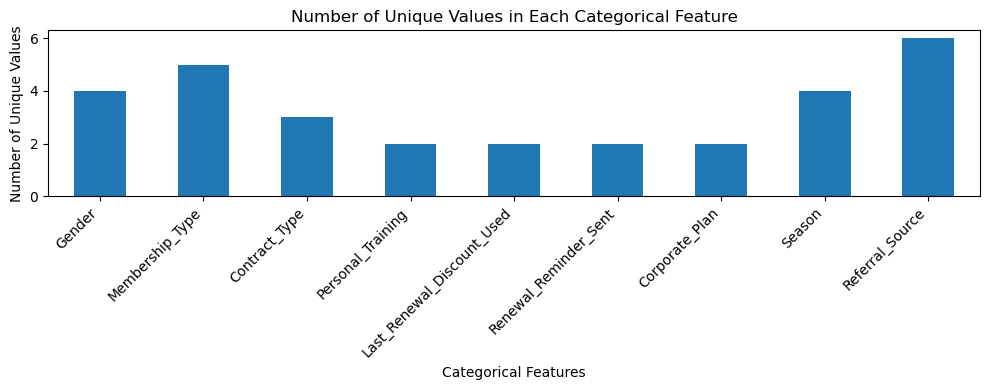

In [21]:
# Create a figure for the categorical unique values chart
plt.figure(figsize=(10, 4))

# Create a bar chart for the number of unique values in each categorical feature
categorical_unique_counts.plot(kind="bar")

# Add a title to the chart
plt.title("Number of Unique Values in Each Categorical Feature")

# Add a label to the x-axis
plt.xlabel("Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Unique Values")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=45, ha="right")

# Adjust the layout so labels do not overlap
plt.tight_layout()

# Save the chart in the outputs folder
plt.savefig("outputs/categorical_unique_values.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## Short Interpretation

The dataset contains both numerical and categorical features. The categorical variables will need to be encoded before model training because machine learning models require numerical input values.

In [22]:
# Create a copy of the original dataset for cleaning
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (416, 21)
Copied dataset shape: (416, 21)


# Step 6: Data Cleaning

Before training a machine learning model, the dataset must be cleaned.

In this step, a copy of the original dataset is created, duplicate rows are removed, and rows with missing target values are dropped if any exist.

Duplicate rows can affect model training because repeated records may give extra weight to the same member information. The target variable should not be filled because it is the value the model is trying to predict.

Missing values in input features will be handled separately in the next step.

In [23]:
# Count duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 6


In [24]:
# Remove duplicate rows and reset the index
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Drop rows where the target variable is missing
# The target variable should not be filled because it is the value the model learns to predict
df_clean = df_clean.dropna(subset=[target_column]).reset_index(drop=True)

# Count duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

# Print the shape of the dataset after removing duplicates
print("Dataset shape after removing duplicates:", df_clean.shape)

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Duplicate rows have been removed.
Dataset shape after removing duplicates: (410, 21)
Number of duplicate rows after cleaning: 0


In [25]:
# Create a duplicate cleaning summary table
duplicate_summary = pd.DataFrame({
    "Cleaning Item": ["Duplicate Rows Before Cleaning", "Duplicate Rows After Cleaning"],
    "Count": [duplicates_before, duplicates_after]
})

# Display duplicate cleaning summary
display(duplicate_summary)

,Cleaning Item,Count
0,Duplicate Rows Before Cleaning,6
1,Duplicate Rows After Cleaning,0


In [26]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Member_ID,Age,Gender,Membership_Type,Monthly_Fee,Months_As_Member,Contract_Type,Avg_Weekly_Visits,Classes_Per_Month,Personal_Training,...,Payment_Issues_Last_6_Months,Satisfaction_Score,Complaint_Count_Last_3_Months,Distance_From_Studio_km,Last_Renewal_Discount_Used,Renewal_Reminder_Sent,Corporate_Plan,Season,Referral_Source,At_Risk_Not_Renewing
0,FS-0001,33,Male,Standard,69,4,Monthly,2.5,2.0,No,...,0,6.4,0,13.7,No,No,No,Spring,Instagram Ad,No
1,FS-0002,24,Female,Standard,69,8,Monthly,4.3,4.0,Yes,...,1,6.5,0,2.7,No,Yes,No,Spring,Community Event,No
2,FS-0003,43,Female,Basic,49,25,6-Month,1.9,1.0,No,...,2,9.7,0,11.4,No,Yes,Yes,Winter,Corporate Partner,Yes
3,FS-0004,57,Prefer not to say,Student,35,27,Annual,2.7,6.0,Yes,...,0,NaN,1,5.9,No,Yes,Yes,Fall,Instagram Ad,No
4,FS-0005,35,Female,Standard,54,1,6-Month,3.1,1.0,No,...,2,7.6,1,5.2,No,Yes,No,Spring,Friend Referral,Yes


## Short Interpretation

Duplicate rows have been removed from the dataset. This helps prevent repeated member records from influencing the model unfairly.

The dataset is now cleaned for duplicate records. In the next step, missing values in the input features will be handled using appropriate methods for numerical and categorical variables.

# Step 7: Handling Missing Values

In this step, missing values in the cleaned dataset are handled.

Missing values can cause problems during model training because machine learning models usually require complete input data.

For this assignment:

* Missing numerical values are filled using the median.
* Missing categorical values are filled using the mode, which is the most frequent category.
* The ID column and target column are excluded from missing-value filling.

This prepares a complete dataset for defining features and training the Decision Tree model.


In [27]:
# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


Member_ID                        0
Age                              0
Gender                           0
Membership_Type                  0
Monthly_Fee                      0
Months_As_Member                 0
Contract_Type                    0
Avg_Weekly_Visits                5
Classes_Per_Month                8
Personal_Training                0
App_Login_Days_Last_30           0
Payment_Issues_Last_6_Months     0
Satisfaction_Score               9
Complaint_Count_Last_3_Months    0
Distance_From_Studio_km          0
Last_Renewal_Discount_Used       0
Renewal_Reminder_Sent            0
Corporate_Plan                   0
Season                           0
Referral_Source                  7
At_Risk_Not_Renewing             0
dtype: int64

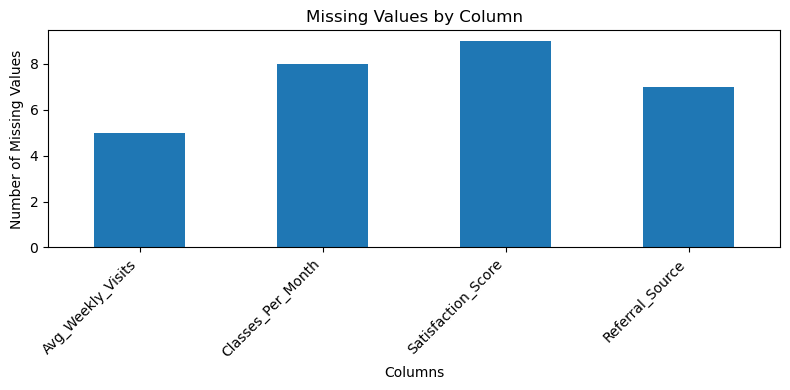

In [28]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Select only columns that have missing values
missing_columns = missing_values_before[missing_values_before > 0]

# Create a bar chart only if there are columns with missing values
if len(missing_columns) > 0:
    
    # Create a figure for the missing values chart
    plt.figure(figsize=(8, 4))

    # Create a bar chart for columns with missing values
    missing_columns.plot(kind="bar")

    # Add a title to the chart
    plt.title("Missing Values by Column")

    # Add a label to the x-axis
    plt.xlabel("Columns")

    # Add a label to the y-axis
    plt.ylabel("Number of Missing Values")

    # Rotate x-axis labels to make them easier to read
    plt.xticks(rotation=45, ha="right")

    # Adjust the layout so labels do not overlap
    plt.tight_layout()

    # Save the chart in the outputs folder
    plt.savefig("outputs/missing_values_by_column.png", dpi=300, bbox_inches="tight")

    # Display the chart
    plt.show()

else:
    print("No missing values found before handling.")

In [29]:
# Create a feature-only dataset for identifying columns to fill
# ID and target columns are excluded because they should not be used for missing-value filling
features_for_missing_value_handling = df_clean.drop(
    columns=[target_column, id_column],
    errors="ignore"
)

# Select numerical columns from the cleaned dataset
numerical_columns_for_cleaning = features_for_missing_value_handling.select_dtypes(
    include=["number"]
).columns.tolist()

# Select categorical columns from the cleaned dataset
categorical_columns_for_cleaning = features_for_missing_value_handling.select_dtypes(
    include=["object"]
).columns.tolist()

# Print numerical columns
print("Numerical columns:")
print(numerical_columns_for_cleaning)

# Print a separator line
print("-" * 50)

# Print categorical columns
print("Categorical columns:")
print(categorical_columns_for_cleaning)

Numerical columns:
['Age', 'Monthly_Fee', 'Months_As_Member', 'Avg_Weekly_Visits', 'Classes_Per_Month', 'App_Login_Days_Last_30', 'Payment_Issues_Last_6_Months', 'Satisfaction_Score', 'Complaint_Count_Last_3_Months', 'Distance_From_Studio_km']
--------------------------------------------------
Categorical columns:
['Gender', 'Membership_Type', 'Contract_Type', 'Personal_Training', 'Last_Renewal_Discount_Used', 'Renewal_Reminder_Sent', 'Corporate_Plan', 'Season', 'Referral_Source']


In [30]:
# Count missing values before filling
missing_before = df_clean.isnull().sum()

# Select numerical columns for missing value filling, excluding ID and target columns
numerical_columns_for_cleaning = df_clean.drop(
    columns=[target_column, id_column],
    errors="ignore"
).select_dtypes(include=["number"]).columns.tolist()

# Select categorical columns for missing value filling, excluding ID and target columns
categorical_columns_for_cleaning = df_clean.drop(
    columns=[target_column, id_column],
    errors="ignore"
).select_dtypes(include=["object"]).columns.tolist()

# Create an empty list to store missing value filling details
missing_value_filling_summary = []

# Fill missing numerical values with the median
for column in numerical_columns_for_cleaning:
    missing_count = df_clean[column].isnull().sum()

    if missing_count > 0:
        fill_value = df_clean[column].median()
        df_clean[column] = df_clean[column].fillna(fill_value)
        missing_value_filling_summary.append(
            [column, "Numerical", missing_count, "Median", fill_value]
        )

# Fill missing categorical values with the mode
for column in categorical_columns_for_cleaning:
    missing_count = df_clean[column].isnull().sum()

    if missing_count > 0:
        fill_value = df_clean[column].mode(dropna=True)[0]
        df_clean[column] = df_clean[column].fillna(fill_value)
        missing_value_filling_summary.append(
            [column, "Categorical", missing_count, "Mode", fill_value]
        )

# Convert missing value filling details into a DataFrame
missing_value_filling_summary = pd.DataFrame(
    missing_value_filling_summary,
    columns=["Column", "Data Type", "Missing Values Filled", "Method", "Fill Value"]
)

# Display missing value filling summary
display(missing_value_filling_summary)

# Check missing values after filling
missing_after = df_clean.isnull().sum()

# Print a title
print("Missing Values After Cleaning")

# Print a separator line
print("-" * 50)

# Display missing values after cleaning
display(missing_after)

# Save the missing value filling summary
missing_value_filling_summary.to_csv(
    "outputs/missing_value_filling_summary.csv",
    index=False
)

,Column,Data Type,Missing Values Filled,Method,Fill Value
0,Avg_Weekly_Visits,Numerical,5,Median,2.5
1,Classes_Per_Month,Numerical,8,Median,3.0
2,Satisfaction_Score,Numerical,9,Median,7.6
3,Referral_Source,Categorical,7,Mode,Friend Referral


Missing Values After Cleaning
--------------------------------------------------


Member_ID                        0
Age                              0
Gender                           0
Membership_Type                  0
Monthly_Fee                      0
Months_As_Member                 0
Contract_Type                    0
Avg_Weekly_Visits                0
Classes_Per_Month                0
Personal_Training                0
App_Login_Days_Last_30           0
Payment_Issues_Last_6_Months     0
Satisfaction_Score               0
Complaint_Count_Last_3_Months    0
Distance_From_Studio_km          0
Last_Renewal_Discount_Used       0
Renewal_Reminder_Sent            0
Corporate_Plan                   0
Season                           0
Referral_Source                  0
At_Risk_Not_Renewing             0
dtype: int64

In [31]:
# Print cleaned dataset shape
print("Cleaned Dataset Shape")

# Print a separator line
print("-" * 50)

# Display the shape of the cleaned dataset
print(df_clean.shape)

Cleaned Dataset Shape
--------------------------------------------------
(410, 21)


## Short Interpretation

The missing values have now been handled.

Numerical missing values were replaced using the median, while categorical missing values were replaced using the mode. The target variable was not filled because it is the value the model is trying to predict.

The dataset is now complete and ready for defining the input features and target variable.

# Step 8: Defining X and y

In this step, the dataset is separated into input features `X` and target variable `y`.

The `Member_ID` column is removed because it is only an identifier and does not provide meaningful information for predicting renewal risk.

In [32]:
# Create X by removing the target column and ID column
X = df_clean.drop(columns=[target_column, id_column])

# Create y by selecting the target column
y = df_clean[target_column]

# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.\n")

# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print X and y shapes
print("Features and Target Shapes")
print("-" * 50)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("-" * 50)
print("\nThe first five rows of X")
# Display the first five rows of X
display(X.head())
print("\n")
print("-" * 50)
print("The first five rows of y")
# Display the first five rows of Y
display(y.head())

X and y have been defined successfully.

Features and Target Shapes
--------------------------------------------------
X shape: (410, 19)
y shape: (410,)
--------------------------------------------------

The first five rows of X


,Age,Gender,Membership_Type,Monthly_Fee,Months_As_Member,Contract_Type,Avg_Weekly_Visits,Classes_Per_Month,Personal_Training,App_Login_Days_Last_30,Payment_Issues_Last_6_Months,Satisfaction_Score,Complaint_Count_Last_3_Months,Distance_From_Studio_km,Last_Renewal_Discount_Used,Renewal_Reminder_Sent,Corporate_Plan,Season,Referral_Source
0,33,Male,Standard,69,4,Monthly,2.5,2.0,No,19,0,6.4,0,13.7,No,No,No,Spring,Instagram Ad
1,24,Female,Standard,69,8,Monthly,4.3,4.0,Yes,30,1,6.5,0,2.7,No,Yes,No,Spring,Community Event
2,43,Female,Basic,49,25,6-Month,1.9,1.0,No,11,2,9.7,0,11.4,No,Yes,Yes,Winter,Corporate Partner
3,57,Prefer not to say,Student,35,27,Annual,2.7,6.0,Yes,16,0,7.6,1,5.9,No,Yes,Yes,Fall,Instagram Ad
4,35,Female,Standard,54,1,6-Month,3.1,1.0,No,7,2,7.6,1,5.2,No,Yes,No,Spring,Friend Referral




--------------------------------------------------
The first five rows of y


0     No
1     No
2    Yes
3     No
4    Yes
Name: At_Risk_Not_Renewing, dtype: object

In [33]:
# Print target class distribution after cleaning
print("Target Class Distribution After Cleaning")
print("-" * 50)

target_counts_clean = y.value_counts()
display(target_counts_clean)

Target Class Distribution After Cleaning
--------------------------------------------------


At_Risk_Not_Renewing
No     248
Yes    162
Name: count, dtype: int64

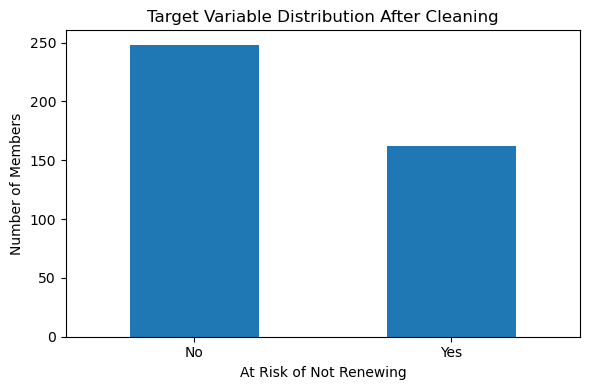

In [34]:
# Create a figure for the target distribution chart after cleaning
plt.figure(figsize=(6, 4))

# Create a bar chart for the cleaned target variable distribution
target_counts_clean.plot(kind="bar")

# Add a title to the chart
plt.title("Target Variable Distribution After Cleaning")

# Add a label to the x-axis
plt.xlabel("At Risk of Not Renewing")

# Add a label to the y-axis
plt.ylabel("Number of Members")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the chart
plt.savefig("outputs/target_distribution_after_cleaning.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## Short Interpretation

The model input features are stored in `X`, and the target variable is stored in `y`. The identifier column `Member_ID` has been removed before model training to avoid misleading the model.

# Step 9: Splitting the Data

The dataset is split into training and testing sets.

The training set is used to train the Decision Tree model, while the testing set is used to evaluate how well the model performs on unseen data. Stratification is used so that the target class distribution is similar in both the training and testing sets.

In [35]:
# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create a table showing the shape of each dataset
split_summary = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
})
# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.\n")

# Display split summary
display(split_summary)

Data has been split into training and testing sets.



,Dataset,Shape
0,X_train,"(328, 19)"
1,X_test,"(82, 19)"
2,y_train,"(328,)"
3,y_test,"(82,)"


In [36]:
# Compare target distribution in training and testing sets
split_target_distribution = pd.DataFrame({
    "Training Set": y_train.value_counts().sort_index(),
    "Testing Set": y_test.value_counts().sort_index()
})

# Display the target distribution in training and testing sets
display(split_target_distribution)

,Training Set,Testing Set
At_Risk_Not_Renewing,,
No,198,50
Yes,130,32


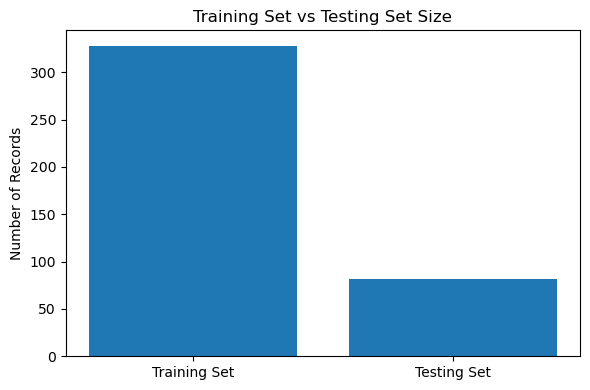

In [37]:
# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]

# Create values for the chart
split_sizes = [len(X_train), len(X_test)]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)

# Add a title to the chart
plt.title("Training Set vs Testing Set Size")

# Add a label to the y-axis
plt.ylabel("Number of Records")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

# Step 10: Preprocessing

Machine learning models require numerical input. Therefore, categorical variables are converted into numerical columns using one-hot encoding.

Numerical variables are passed through without scaling because Decision Trees do not require feature scaling.

The preprocessor is fitted only on the training data and then applied to the testing data. This helps avoid data leakage.

In [38]:
# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print numerical features
print("Numerical features:")
print(numerical_features)

# Print a separator line
print("-" * 50)

# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Age', 'Monthly_Fee', 'Months_As_Member', 'Avg_Weekly_Visits', 'Classes_Per_Month', 'App_Login_Days_Last_30', 'Payment_Issues_Last_6_Months', 'Satisfaction_Score', 'Complaint_Count_Last_3_Months', 'Distance_From_Studio_km']
--------------------------------------------------
Categorical features:
['Gender', 'Membership_Type', 'Contract_Type', 'Personal_Training', 'Last_Renewal_Discount_Used', 'Renewal_Reminder_Sent', 'Corporate_Plan', 'Season', 'Referral_Source']


In [39]:
# Create a one-hot encoder for categorical variables
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_encoder, categorical_features),
        ("numerical", "passthrough", numerical_features)
    ],
    remainder="drop"
)

# Fit the preprocessor on the training data and transform the training data
X_train_processed_array = preprocessor.fit_transform(X_train)

# Transform the testing data using the fitted preprocessor
X_test_processed_array = preprocessor.transform(X_test)

# Get the names of the processed features
processed_feature_names = preprocessor.get_feature_names_out()

# Convert processed training data into a DataFrame
X_train_processed = pd.DataFrame(
    X_train_processed_array,
    columns=processed_feature_names,
    index=X_train.index
)

# Convert processed testing data into a DataFrame
X_test_processed = pd.DataFrame(
    X_test_processed_array,
    columns=processed_feature_names,
    index=X_test.index
)

# Create a preprocessing summary table
preprocessing_summary = pd.DataFrame({
    "Dataset": [
        "X_train before preprocessing",
        "X_train after preprocessing",
        "X_test before preprocessing",
        "X_test after preprocessing"
    ],
    "Shape": [
        X_train.shape,
        X_train_processed.shape,
        X_test.shape,
        X_test_processed.shape
    ]
})

# Display preprocessing summary
display(preprocessing_summary)

,Dataset,Shape
0,X_train before preprocessing,"(328, 19)"
1,X_train after preprocessing,"(328, 40)"
2,X_test before preprocessing,"(82, 19)"
3,X_test after preprocessing,"(82, 40)"


In [40]:
# Print the total number of processed features
print("Number of processed features:", len(processed_feature_names))

# Print a separator line
print("-" * 50)

# Display the processed feature names
print(processed_feature_names.tolist())

# Display the first five rows of the processed training data
display(X_train_processed.head())


Number of processed features: 40
--------------------------------------------------
['categorical__Gender_Female', 'categorical__Gender_Male', 'categorical__Gender_Non-binary', 'categorical__Gender_Prefer not to say', 'categorical__Membership_Type_Basic', 'categorical__Membership_Type_Family', 'categorical__Membership_Type_Premium', 'categorical__Membership_Type_Standard', 'categorical__Membership_Type_Student', 'categorical__Contract_Type_6-Month', 'categorical__Contract_Type_Annual', 'categorical__Contract_Type_Monthly', 'categorical__Personal_Training_No', 'categorical__Personal_Training_Yes', 'categorical__Last_Renewal_Discount_Used_No', 'categorical__Last_Renewal_Discount_Used_Yes', 'categorical__Renewal_Reminder_Sent_No', 'categorical__Renewal_Reminder_Sent_Yes', 'categorical__Corporate_Plan_No', 'categorical__Corporate_Plan_Yes', 'categorical__Season_Fall', 'categorical__Season_Spring', 'categorical__Season_Summer', 'categorical__Season_Winter', 'categorical__Referral_Source_Com

,categorical__Gender_Female,categorical__Gender_Male,categorical__Gender_Non-binary,categorical__Gender_Prefer not to say,categorical__Membership_Type_Basic,categorical__Membership_Type_Family,categorical__Membership_Type_Premium,categorical__Membership_Type_Standard,categorical__Membership_Type_Student,categorical__Contract_Type_6-Month,...,numerical__Age,numerical__Monthly_Fee,numerical__Months_As_Member,numerical__Avg_Weekly_Visits,numerical__Classes_Per_Month,numerical__App_Login_Days_Last_30,numerical__Payment_Issues_Last_6_Months,numerical__Satisfaction_Score,numerical__Complaint_Count_Last_3_Months,numerical__Distance_From_Studio_km
76,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,29.0,54.0,49.0,3.5,10.0,16.0,0.0,7.2,0.0,7.2
296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,26.0,34.0,2.0,0.3,1.0,17.0,0.0,3.6,0.0,4.6
153,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,48.0,119.0,12.0,1.4,2.0,11.0,3.0,4.4,0.0,4.5
219,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,21.0,54.0,6.0,3.6,2.0,17.0,0.0,7.9,0.0,6.1
67,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,54.0,109.0,25.0,3.2,6.0,24.0,0.0,7.6,0.0,4.0


## Short Interpretation

Categorical variables have been converted into numerical columns using one-hot encoding. Numerical variables were kept unchanged because Decision Tree models do not require scaling.

After preprocessing, the number of columns increased because each categorical category was converted into a separate numerical column. The processed training and testing datasets are now ready for training the Decision Tree model.

# Step 11: Train the Decision Tree Model

In this step, a Decision Tree classification model is trained using the processed training data.

The model is given a maximum depth of 4 to keep it reasonably simple and interpretable while reducing the risk of overfitting.

In [41]:
# Create a Decision Tree classification model
decision_tree_model = DecisionTreeClassifier(
    # Limit the depth of the tree to make it easier to understand
    max_depth=4,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [42]:
# Train the Decision Tree model using the processed training data
decision_tree_model.fit(X_train_processed, y_train)

# Print a confirmation message
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [43]:
# Print the model information
print("Decision Tree Model Information")

# Print a separator line
print("-" * 50)

# Display model details
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


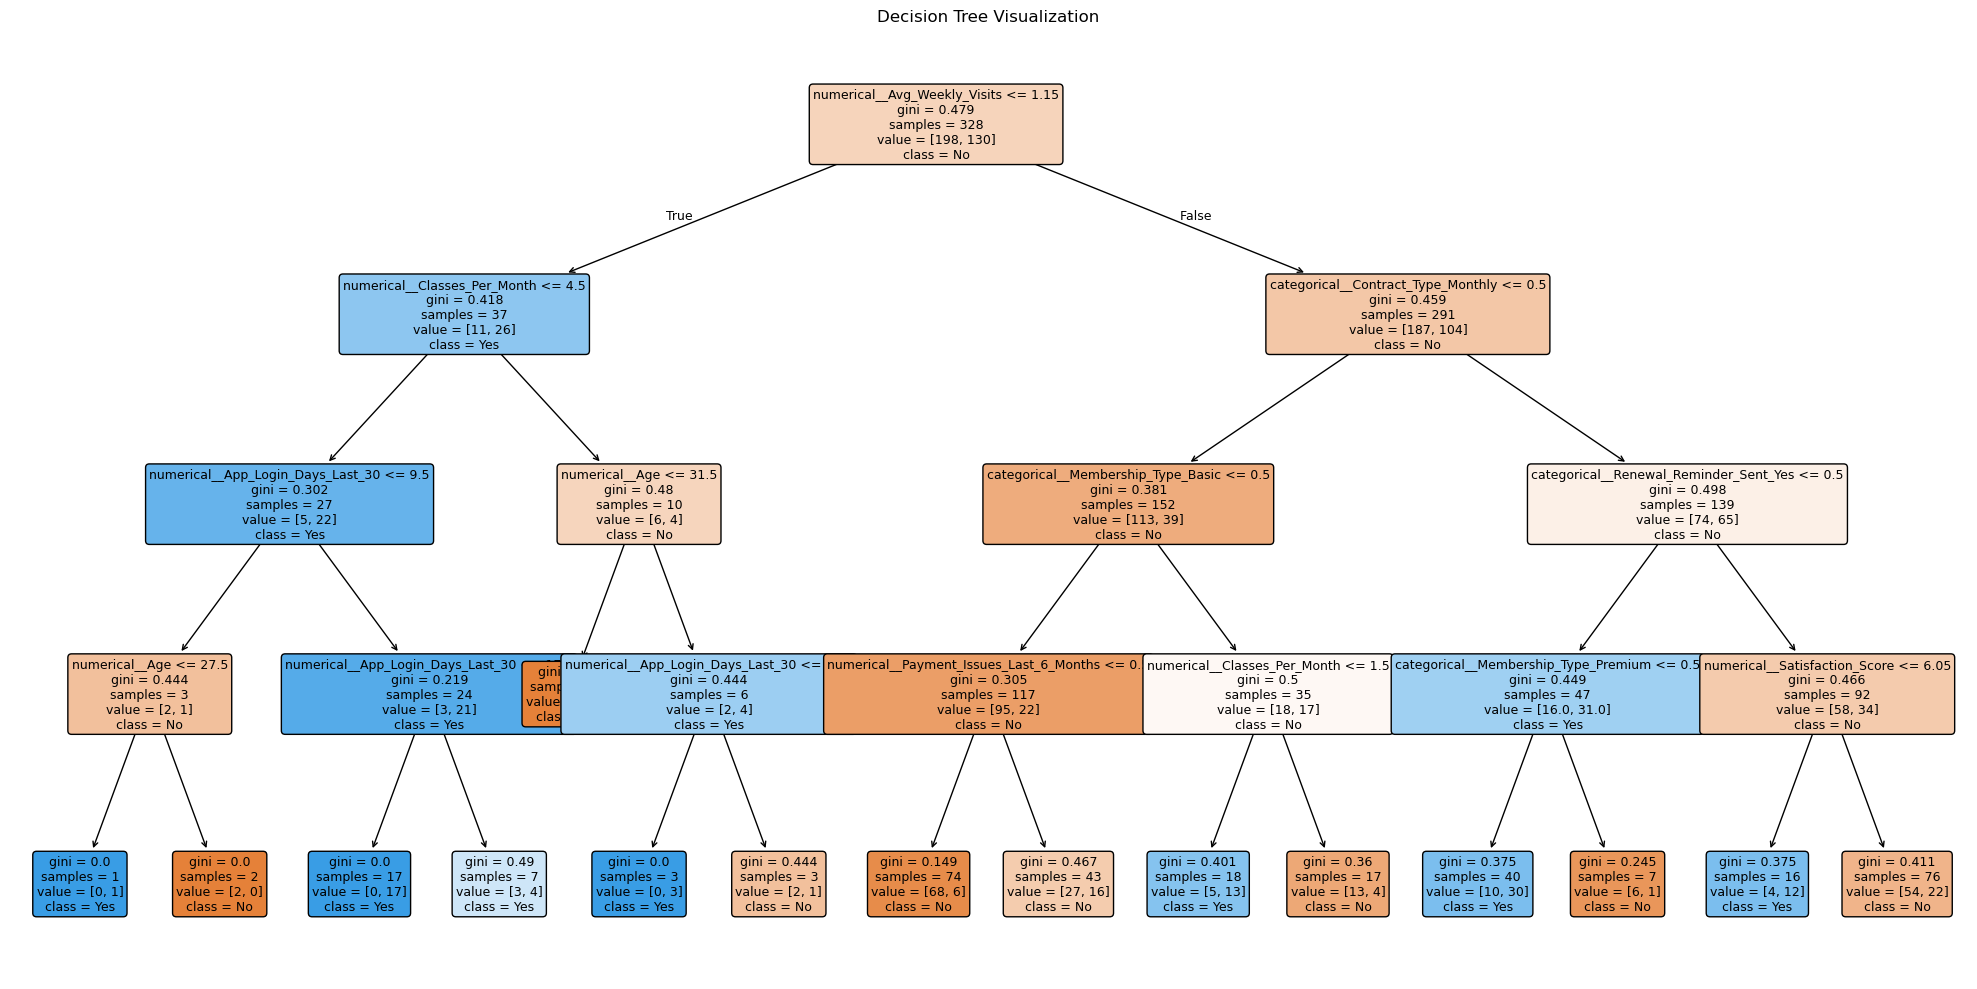

In [44]:
# Create a visual representation of the Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=processed_feature_names,
    class_names=decision_tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

# Add title
plt.title("Decision Tree Visualization")

# Adjust layout
plt.tight_layout()

# Save the tree visualization
plt.savefig("outputs/decision_tree_visualization.png", dpi=300, bbox_inches="tight")

# Display the tree
plt.show()

## Short Interpretation

The Decision Tree model has been trained using the processed training data.

The model was trained with `max_depth=4` to keep it reasonably simple and interpretable. Limiting the tree depth helps reduce the risk of creating an overly complex tree.

The model is now ready to make predictions on the training and testing datasets.

# Step 12: Make Predictions

After training the model, predictions are made for both the training and testing data.

Testing predictions are especially important because they show how well the model performs on member records it did not see during training.

In [45]:
# Make predictions on the training data
y_train_pred = decision_tree_model.predict(X_train_processed)

# Make predictions on the testing data
y_test_pred = decision_tree_model.predict(X_test_processed)

# Create a DataFrame to compare actual and predicted values
actual_predicted_values = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

# Print a title
print("Actual vs Predicted Values")

# Print a separator line
print("-" * 50)

# Display the first 10 actual and predicted values
display(actual_predicted_values.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
1,No,No
255,Yes,Yes
359,Yes,No
184,No,No
4,Yes,No
130,Yes,No
322,No,Yes
386,Yes,No
328,No,No
228,Yes,No


## Short Interpretation

The trained Decision Tree model has produced predictions for the testing data. These predictions will be compared with the actual target values to evaluate model performance.

# Step 13: Evaluate Model Performance

In this step, the Decision Tree model is evaluated using accuracy, precision, recall, and F1-score.

For FitLife, recall for the `Yes` class is especially important because missing members who are truly at risk may reduce the opportunity to take proactive retention actions.

In [46]:
# Define the class order
class_order = ["No", "Yes"]

# Count actual class values in the testing set
actual_counts = y_test.value_counts().reindex(class_order, fill_value=0)

# Count predicted class values from the Decision Tree model
predicted_counts = pd.Series(y_test_pred).value_counts().reindex(class_order, fill_value=0)

# Create a comparison table for actual and predicted class counts
class_count_comparison = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
})

# Display the comparison table
display(class_count_comparison)

,Actual,Predicted
No,50,56
Yes,32,26


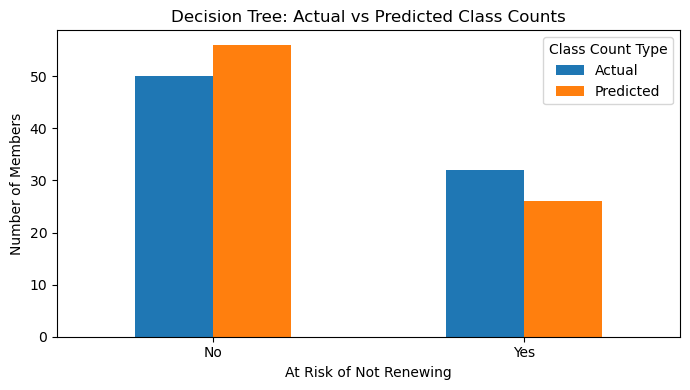

In [47]:
# Create a bar chart for actual and predicted class counts
ax = class_count_comparison.plot(
    kind="bar",
    figsize=(7, 4)
)

# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")

# Add a label to the x-axis
plt.xlabel("At Risk of Not Renewing")

# Add a label to the y-axis
plt.ylabel("Number of Members")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Add legend title
plt.legend(title="Class Count Type")

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/actual_vs_predicted_class_counts.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

In [48]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_test_pred)

# Calculate precision for the Yes class
precision = precision_score(y_test, y_test_pred, pos_label="Yes")

# Calculate recall for the Yes class
recall = recall_score(y_test, y_test_pred, pos_label="Yes")

# Calculate F1-score for the Yes class
f1 = f1_score(y_test, y_test_pred, pos_label="Yes")

# Create a DataFrame for model evaluation results
evaluation_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

# Display the evaluation results
display(evaluation_results)

# Save the evaluation results
evaluation_results.to_csv("outputs/decision_tree_evaluation_results.csv", index=False)

,Metric,Score
0,Accuracy,0.731707
1,Precision,0.692308
2,Recall,0.562500
3,F1-Score,0.620690


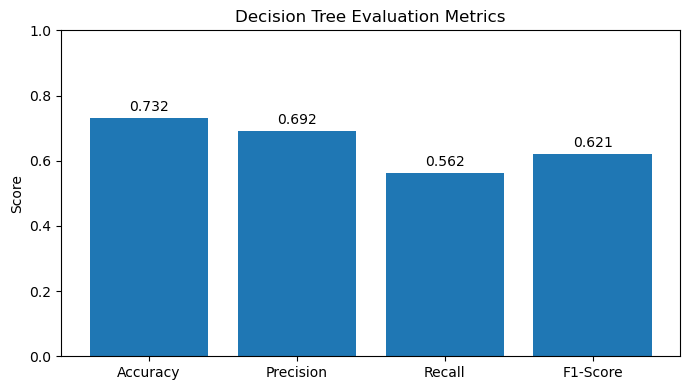

In [49]:
# Create a figure for the evaluation metrics chart
plt.figure(figsize=(7, 4))

# Create a bar chart for the evaluation metrics
plt.bar(evaluation_results["Metric"], evaluation_results["Score"])

# Add a title to the chart
plt.title("Decision Tree Evaluation Metrics")

# Add a label to the y-axis
plt.ylabel("Score")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Add score values on top of each bar
for index, value in enumerate(evaluation_results["Score"]):
    plt.text(index, value + 0.02, round(value, 3), ha="center")

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/decision_tree_evaluation_metrics.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

In [50]:
# Print the classification report
print("Classification Report")

# Print a separator line
print("-" * 50)

# Display the classification report
print(classification_report(y_test, y_test_pred))

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.75      0.84      0.79        50
         Yes       0.69      0.56      0.62        32

    accuracy                           0.73        82
   macro avg       0.72      0.70      0.71        82
weighted avg       0.73      0.73      0.73        82



## Short Interpretation

The model has been evaluated using the testing data. Accuracy shows the overall percentage of correct predictions, while precision, recall, and F1-score provide more detail about how well the model identifies members at risk of not renewing.

The recall value shows that the model identifies 56.25% of the actual at-risk members. This means some at-risk members are still missed, so FitLife should use the model as a screening tool rather than relying on it completely.

The actual vs predicted class count table and chart show whether the model is predicting the two target classes in a balanced way. The next step checks whether the model may be overfitting by comparing training accuracy and testing accuracy.

# Step 14: Training vs Testing Accuracy and Overfitting

Overfitting happens when a model performs very well on training data but performs much worse on testing data.

To check this, training accuracy and testing accuracy are compared. A large difference may suggest overfitting, while a smaller difference suggests better generalization.

In [51]:
# Calculate training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Create a table to compare training and testing accuracy
accuracy_table = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set"],
    "Accuracy": [train_accuracy, test_accuracy]
})

# Display the accuracy comparison table
display(accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.780488
1,Testing Set,0.731707


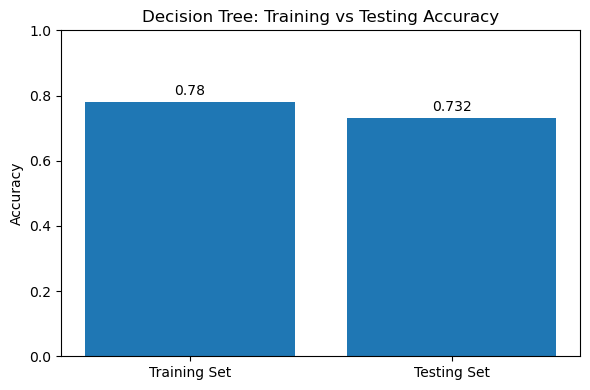

In [52]:
# Create a figure for the accuracy comparison chart
plt.figure(figsize=(6, 4))

# Create a bar chart for training and testing accuracy
plt.bar(accuracy_table["Evaluation Set"], accuracy_table["Accuracy"])

# Add a title to the chart
plt.title("Decision Tree: Training vs Testing Accuracy")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Add accuracy values on top of each bar
for index, value in enumerate(accuracy_table["Accuracy"]):
    plt.text(index, value + 0.02, round(value, 3), ha="center")

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/training_testing_accuracy_comparison.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

In [53]:
# Calculate the difference between training and testing accuracy
accuracy_difference = train_accuracy - test_accuracy

# Create an overfitting summary table
overfitting_summary = pd.DataFrame({
    "Item": ["Training Accuracy", "Testing Accuracy", "Accuracy Difference"],
    "Value": [train_accuracy, test_accuracy, accuracy_difference]
})

# Display the overfitting summary
display(overfitting_summary)

# Save the overfitting summary
overfitting_summary.to_csv("outputs/overfitting_summary.csv", index=False)

,Item,Value
0,Training Accuracy,0.780488
1,Testing Accuracy,0.731707
2,Accuracy Difference,0.048780


## Short Interpretation

The training accuracy is higher than the testing accuracy, which is expected because the model learns from the training data. However, the difference is not very large, so the model does not show strong signs of overfitting.

The model appears to generalize reasonably well, but the testing performance should still be interpreted carefully because this is a single Decision Tree model.

# Step 15: Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the model.

For this assignment:

- **True Positive**: the model correctly predicts that a member is at risk.
- **False Positive**: the model predicts that a member is at risk, but the member is not actually at risk.
- **False Negative**: the model predicts that a member is not at risk, but the member is actually at risk.
- **True Negative**: the model correctly predicts that a member is not at risk.

In [54]:
# Create the confusion matrix for the Decision Tree model
cm = confusion_matrix(y_test, y_test_pred, labels=["No", "Yes"])

# Create a DataFrame to show the confusion matrix in a readable table format
confusion_matrix_table = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

# Display the confusion matrix table
display(confusion_matrix_table)

,Predicted No,Predicted Yes
Actual No,42,8
Actual Yes,14,18


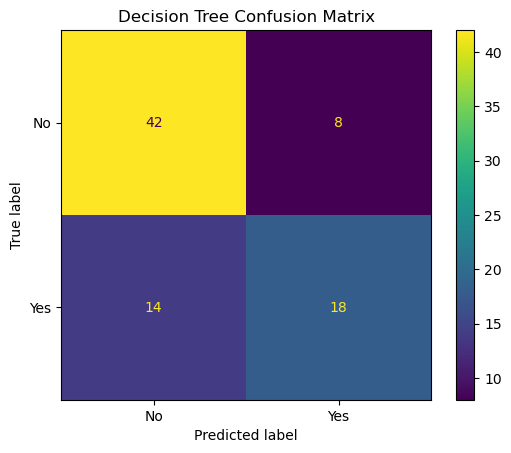

In [55]:
# Create a visual display for the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

# Plot the confusion matrix
disp.plot()

# Add a title
plt.title("Decision Tree Confusion Matrix")

# Save the chart
plt.savefig("outputs/decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

In [56]:
# Store confusion matrix values for business interpretation
true_negative = cm[0, 0]
false_positive = cm[0, 1]
false_negative = cm[1, 0]
true_positive = cm[1, 1]

# Create a confusion matrix interpretation table
confusion_interpretation_table = pd.DataFrame({
    "Confusion Matrix Item": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Value": [true_negative, false_positive, false_negative, true_positive],
    "Business Meaning": [
        "Members correctly predicted as not at risk",
        "Members incorrectly predicted as at risk",
        "At-risk members incorrectly predicted as not at risk",
        "At-risk members correctly predicted as at risk"
    ]
})

# Display the interpretation table
display(confusion_interpretation_table)

,Confusion Matrix Item,Value,Business Meaning
0,True Negative,42,Members correctly predicted as not at risk
1,False Positive,8,Members incorrectly predicted as at risk
2,False Negative,14,At-risk members incorrectly predicted as not a...
3,True Positive,18,At-risk members correctly predicted as at risk


## Short Interpretation

The confusion matrix gives a detailed view of the model's correct and incorrect predictions. The model correctly identified 18 at-risk members and correctly classified 42 members as not at risk. However, it missed 14 actual at-risk members. These false negatives are important because FitLife may fail to contact members who need retention support.

# Step 16: Feature Importance

Decision Trees can show which features were most important for making predictions.

Feature importance helps FitLife understand which member characteristics or behaviors the model relied on most when predicting renewal risk.

In [57]:
# Get feature importance values from the Decision Tree model
importance_values = decision_tree_model.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": importance_values
})

# Clean feature names for readability
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

# Sort features from most important to least important
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display the top 10 most important features
top_10_features = feature_importance_df.head(10)

# Display top 10 feature importance table
display(top_10_features)

# Save the full feature importance table
feature_importance_df.to_csv("outputs/decision_tree_feature_importance.csv", index=False)

,Feature,Importance
33,Avg_Weekly_Visits,0.145642
34,Classes_Per_Month,0.123850
11,Contract_Type_Monthly,0.120326
37,Satisfaction_Score,0.104301
17,Renewal_Reminder_Sent_Yes,0.097349
4,Membership_Type_Basic,0.088827
35,App_Login_Days_Last_30,0.087803
36,Payment_Issues_Last_6_Months,0.085698
6,Membership_Type_Premium,0.081710
30,Age,0.064494


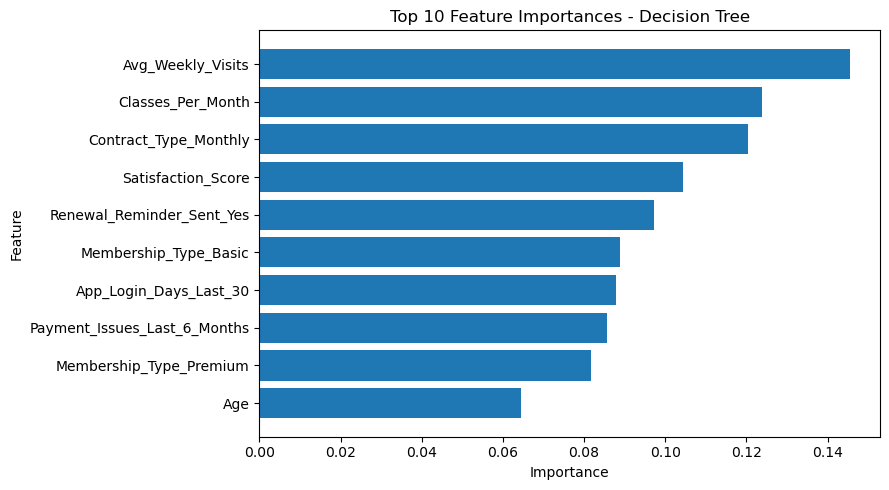

In [58]:
# Create a horizontal bar chart for the top 10 important features
plt.figure(figsize=(9, 5))

# Plot feature importance
plt.barh(top_10_features["Feature"][::-1], top_10_features["Importance"][::-1])

# Add title and labels
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Adjust layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/top_10_feature_importance.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## Short Interpretation

The feature importance results show which variables the Decision Tree used most when predicting renewal risk. Features with higher importance values had more influence on the model's decision rules.

Features with zero importance were not used by this specific Decision Tree model. This does not necessarily mean they have no business value; it only means this trained tree did not rely on them for its splits.

Some important features are one-hot encoded categories, such as `Contract_Type_Monthly` and `Membership_Type_Basic`. This means the model found those specific membership categories useful when predicting renewal risk.

# Step 17: Business Interpretation

This step explains what the model results mean for FitLife from a business perspective.

The model can support retention decisions by helping FitLife identify members who may require proactive attention before they decide not to renew.

In [59]:
# Create a model results summary table
model_results_summary = pd.DataFrame({
    "Result Area": [
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy Difference",
        "Precision for Yes",
        "Recall for Yes",
        "F1-Score for Yes",
        "True Positives",
        "False Positives",
        "False Negatives",
        "True Negatives"
    ],
    "Value": [
        train_accuracy,
        test_accuracy,
        accuracy_difference,
        precision,
        recall,
        f1,
        true_positive,
        false_positive,
        false_negative,
        true_negative
    ]
})

# Display the model results summary
display(model_results_summary)

# Save the model results summary
model_results_summary.to_csv("outputs/model_results_summary.csv", index=False)

,Result Area,Value
0,Training Accuracy,0.780488
1,Testing Accuracy,0.731707
2,Accuracy Difference,0.048780
3,Precision for Yes,0.692308
4,Recall for Yes,0.562500
5,F1-Score for Yes,0.620690
6,True Positives,18.000000
7,False Positives,8.000000
8,False Negatives,14.000000
9,True Negatives,42.000000


## Business Interpretation

The Decision Tree model achieved a testing accuracy of approximately **73%**, which means it correctly classified about seven out of ten members in the testing data.

The model's precision for the `Yes` class is approximately **69%**. This means that when the model predicted a member as at risk, many of those predictions were correct. However, the recall for the `Yes` class is approximately **56%**, which means the model identified a little over half of the actual at-risk members.

For FitLife, recall for the `Yes` class is especially important because a false negative means the model missed a member who is actually at risk of not renewing. These members may not receive proactive retention support, which could lead to preventable churn.

A false positive means the model predicted that a member was at risk even though the member was not actually at risk. This may lead to unnecessary follow-up or retention offers, but this is usually less costly than missing a truly at-risk member.

The most important features suggest that engagement, class participation, contract type, satisfaction, renewal reminders, membership type, app usage, and payment issues are useful signals for predicting renewal risk. FitLife can use these insights to focus retention actions on members who show lower engagement, lower satisfaction, payment difficulties, or risk-related membership patterns.

# Step 18: Limitations and Human Judgment

Although the Decision Tree model is useful, it has limitations.

The model is based only on the variables available in the dataset. It may not include all real reasons why members decide not to renew, such as relocation, health issues, family responsibilities, competitor offers, work schedule changes, or personal financial constraints.

The model also identifies patterns, not guaranteed causes. For example, a feature may be important for prediction, but that does not prove it directly causes renewal risk.

The dataset is relatively small, so the model results may change if FitLife collects more member records over time.

Therefore, FitLife should use the model as a decision-support tool, not as a replacement for human judgment. Managers should review model predictions together with staff knowledge, member communication history, and business context before taking action.

# Step 19: Final Conclusion

This notebook built a Decision Tree classification model to predict whether a FitLife Studio member is at risk of not renewing their membership.

The notebook followed an assignment-focused machine learning workflow: understanding the business problem, loading and inspecting the dataset, cleaning the data, preparing features and target variable, splitting the data, preprocessing categorical variables, training a Decision Tree model, evaluating performance, checking overfitting, analyzing feature importance, and interpreting the results from a business perspective.

The model provides useful support for FitLife's retention strategy by identifying members who may need proactive attention. However, because the model does not capture every possible reason for membership churn, its predictions should be used together with human judgment and business context.